In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

CHAR_DIR = BASE_PATH / "outputs" / "dataset_characterization"
MODEL_DIR = BASE_PATH / "outputs" / "densenet201_baseline"

OUT_DIR = BASE_PATH / "outputs" / "combined_normalization_test"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_model.keras"

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]
IMG_SIZE = (250, 250)
BATCH_SIZE = 4

print("Model path:", MODEL_PATH)
print("Output folder:", OUT_DIR)

Model path: E:\Thesis\outputs\densenet201_baseline\best_model.keras
Output folder: E:\Thesis\outputs\combined_normalization_test


In [3]:
summary = pd.read_csv(CHAR_DIR / "dataset_summary.csv")
print(summary[["dataset", "mean_r", "std_r", "mean_g", "std_g", "mean_b", "std_b", "mean_brightness", "mean_contrast"]])

ham_row = summary.loc[summary["dataset"] == "HAM10000"].iloc[0]
pad_row = summary.loc[summary["dataset"] == "PAD_UFES_20"].iloc[0]

ham_mean_rgb = np.array([ham_row["mean_r"], ham_row["mean_g"], ham_row["mean_b"]], dtype=np.float32)
ham_std_rgb  = np.array([ham_row["std_r"],  ham_row["std_g"],  ham_row["std_b"]],  dtype=np.float32)

ham_mean_brightness = float(ham_row["mean_brightness"])
ham_mean_contrast = float(ham_row["mean_contrast"])

pad_mean_rgb = np.array([pad_row["mean_r"], pad_row["mean_g"], pad_row["mean_b"]], dtype=np.float32)
pad_std_rgb  = np.array([pad_row["std_r"],  pad_row["std_g"],  pad_row["std_b"]],  dtype=np.float32)

pad_mean_brightness = float(pad_row["mean_brightness"])
pad_mean_contrast = float(pad_row["mean_contrast"])

print("HAM mean RGB:", ham_mean_rgb)
print("HAM std RGB :", ham_std_rgb)
print("HAM mean brightness:", ham_mean_brightness)
print("HAM mean contrast:", ham_mean_contrast)

print("PAD mean RGB:", pad_mean_rgb)
print("PAD std RGB :", pad_std_rgb)
print("PAD mean brightness:", pad_mean_brightness)
print("PAD mean contrast:", pad_mean_contrast)

       dataset      mean_r      std_r      mean_g      std_g      mean_b  \
0     HAM10000  196.677987  24.752347  138.926531  22.273621  144.808617   
1  PAD_UFES_20  169.898708  26.212480  132.983700  23.253908  117.593489   

       std_b  mean_brightness  mean_contrast  
0  24.730965       156.864774      28.426130  
1  26.141327       142.266803      25.266878  
HAM mean RGB: [196.678   138.92653 144.80862]
HAM std RGB : [24.752346 22.27362  24.730965]
HAM mean brightness: 156.8647741614629
HAM mean contrast: 28.42613021049315
PAD mean RGB: [169.89871 132.9837  117.59349]
PAD std RGB : [26.21248  23.253908 26.141327]
PAD mean brightness: 142.26680337604984
PAD mean contrast: 25.26687759475512


In [4]:
pad = pd.read_csv(PAD_PATH / "metadata.csv")

PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print(pad_4["exists"].value_counts())
print(pad_4["label"].value_counts())

exists
True    1871
Name: count, dtype: int64
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [5]:
def combined_normalize(image_path, out_path, src_mean_rgb, src_std_rgb, target_brightness, target_contrast, tgt_mean_rgb, tgt_std_rgb):
    """
    Combined normalization:
    1) Match channel-wise RGB mean/std to source
    2) Adjust luminance mean/contrast to source
    """
    eps = 1e-8

    img = Image.open(image_path).convert("RGB")
    arr = np.array(img).astype(np.float32)

    # ----------------------------
    # Step 1: Color normalization
    # ----------------------------
    color_out = np.zeros_like(arr, dtype=np.float32)
    for c in range(3):
        ch = arr[:, :, c]
        ch_norm = (ch - tgt_mean_rgb[c]) / (tgt_std_rgb[c] + eps)
        ch_out = ch_norm * src_std_rgb[c] + src_mean_rgb[c]
        color_out[:, :, c] = ch_out

    color_out = np.clip(color_out, 0, 255)

    # ----------------------------
    # Step 2: Brightness + contrast
    # on luminance channel
    # ----------------------------
    lum = 0.299 * color_out[:, :, 0] + 0.587 * color_out[:, :, 1] + 0.114 * color_out[:, :, 2]
    cur_mean = float(lum.mean())
    cur_std = float(lum.std())

    if cur_std < eps:
        cur_std = eps

    # adjust luminance to target mean and contrast
    desired_lum = (lum - cur_mean) * (target_contrast / cur_std) + target_brightness
    desired_lum = np.clip(desired_lum, 0, 255)

    # preserve color ratios by scaling RGB with luminance ratio
    scale = desired_lum / (lum + eps)
    out = color_out * scale[:, :, None]
    out = np.clip(out, 0, 255).astype(np.uint8)

    Image.fromarray(out).save(out_path)

In [6]:
NORMALIZED_DIR = OUT_DIR / "PAD_UFES_20_combined_normalized_to_HAM"
NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)

normalized_paths = []

for _, row in pad_4.iterrows():
    original_path = row["image_path"]
    filename = os.path.basename(original_path)
    out_path = NORMALIZED_DIR / filename

    if not out_path.exists():
        combined_normalize(
            image_path=original_path,
            out_path=out_path,
            src_mean_rgb=ham_mean_rgb,
            src_std_rgb=ham_std_rgb,
            target_brightness=ham_mean_brightness,
            target_contrast=ham_mean_contrast,
            tgt_mean_rgb=pad_mean_rgb,
            tgt_std_rgb=pad_std_rgb
        )

    normalized_paths.append(str(out_path))

pad_norm = pad_4.copy()
pad_norm["image_path"] = normalized_paths

print("Normalized images saved:", len(normalized_paths))
print(pad_norm[["img_id", "label", "image_path"]].head())

Normalized images saved: 1871
                  img_id label  \
0  PAT_1516_1765_530.png   NEV   
1     PAT_46_881_939.png   BCC   
2  PAT_1545_1867_547.png   ACK   
3  PAT_1989_4061_934.png   ACK   
4   PAT_684_1302_588.png   BCC   

                                          image_path  
0  E:\Thesis\outputs\combined_normalization_test\...  
1  E:\Thesis\outputs\combined_normalization_test\...  
2  E:\Thesis\outputs\combined_normalization_test\...  
3  E:\Thesis\outputs\combined_normalization_test\...  
4  E:\Thesis\outputs\combined_normalization_test\...  


In [7]:
def mean_brightness(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32)
    lum = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
    return float(lum.mean())

def luminance_contrast(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32)
    lum = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
    return float(lum.std())

sample_original = pad_4["image_path"].sample(5, random_state=42).tolist()
sample_norm = [str(NORMALIZED_DIR / os.path.basename(p)) for p in sample_original]

for o, n in zip(sample_original, sample_norm):
    print(
        os.path.basename(o),
        "orig_brightness=", round(mean_brightness(o), 2),
        "norm_brightness=", round(mean_brightness(n), 2),
        "orig_contrast=", round(luminance_contrast(o), 2),
        "norm_contrast=", round(luminance_contrast(n), 2)
    )

PAT_1571_2484_488.png orig_brightness= 149.8 norm_brightness= 156.34 orig_contrast= 17.02 norm_contrast= 28.36
PAT_567_1076_545.png orig_brightness= 152.43 norm_brightness= 156.36 orig_contrast= 29.81 norm_contrast= 28.43
PAT_46_880_140.png orig_brightness= 143.68 norm_brightness= 156.37 orig_contrast= 18.67 norm_contrast= 28.43
PAT_545_1030_854.png orig_brightness= 149.6 norm_brightness= 156.37 orig_contrast= 15.48 norm_contrast= 28.41
PAT_279_429_142.png orig_brightness= 150.03 norm_brightness= 156.36 orig_contrast= 31.19 norm_contrast= 28.43


In [8]:
pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

pad_original_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

pad_norm_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_norm,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Original PAD samples:", pad_original_generator.samples)
print("Normalized PAD samples:", pad_norm_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Found 1871 validated image filenames belonging to 4 classes.
Original PAD samples: 1871
Normalized PAD samples: 1871


In [9]:
model = load_model(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

Loaded model: E:\Thesis\outputs\densenet201_baseline\best_model.keras


In [10]:
def evaluate_generator(model, generator):
    loss, acc = model.evaluate(generator, verbose=1)
    probs = model.predict(generator, verbose=1)
    preds = np.argmax(probs, axis=1)
    true = generator.classes
    return loss, acc, probs, preds, true

In [11]:
orig_loss, orig_acc, orig_probs, orig_preds, orig_true = evaluate_generator(
    model, pad_original_generator
)

print("Original PAD Accuracy:", orig_acc)
print("Original PAD Loss:", orig_loss)

468/468 [==============================] - 131s 260ms/step
Original PAD Accuracy: 0.2891501784324646
Original PAD Loss: 3.0000994205474854


In [12]:
norm_loss, norm_acc, norm_probs, norm_preds, norm_true = evaluate_generator(
    model, pad_norm_generator
)

print("Combined-Normalized PAD Accuracy:", norm_acc)
print("Combined-Normalized PAD Loss:", norm_loss)

468/468 [==============================] - 152s 325ms/step
Combined-Normalized PAD Accuracy: 0.2741849422454834
Combined-Normalized PAD Loss: 2.798041582107544


In [13]:
def compute_metrics(true_classes, pred_classes, pred_probs, class_names):
    acc = accuracy_score(true_classes, pred_classes)
    prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
    rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
    f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

    true_onehot = to_categorical(true_classes, num_classes=len(class_names))
    auc = roc_auc_score(
        true_onehot,
        pred_probs,
        multi_class="ovr",
        average="macro"
    )

    report = classification_report(
        true_classes,
        pred_classes,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(true_classes, pred_classes)

    return acc, prec, rec, f1, auc, report, cm

In [14]:
orig_acc_m, orig_prec, orig_rec, orig_f1, orig_auc, orig_report, orig_cm = compute_metrics(
    orig_true, orig_preds, orig_probs, CLASS_NAMES
)

print("=== Original PAD ===")
print("Accuracy :", orig_acc_m)
print("Precision:", orig_prec)
print("Recall   :", orig_rec)
print("F1 Score :", orig_f1)
print("AUC      :", orig_auc)
print(orig_report)

=== Original PAD ===
Accuracy : 0.28915018706574025
Precision: 0.29792286744381263
Recall   : 0.34610476349299785
F1 Score : 0.21773694454600206
AUC      : 0.6664067795001829
              precision    recall  f1-score   support

         ACK       0.28      0.03      0.06       730
         BCC       0.68      0.34      0.45       845
         MEL       0.05      0.08      0.06        52
         NEV       0.18      0.94      0.30       244

    accuracy                           0.29      1871
   macro avg       0.30      0.35      0.22      1871
weighted avg       0.44      0.29      0.27      1871



In [15]:
norm_acc_m, norm_prec, norm_rec, norm_f1, norm_auc, norm_report, norm_cm = compute_metrics(
    norm_true, norm_preds, norm_probs, CLASS_NAMES
)

print("=== Combined-Normalized PAD ===")
print("Accuracy :", norm_acc_m)
print("Precision:", norm_prec)
print("Recall   :", norm_rec)
print("F1 Score :", norm_f1)
print("AUC      :", norm_auc)
print(norm_report)

=== Combined-Normalized PAD ===
Accuracy : 0.2741849278460716
Precision: 0.2992374016940098
Recall   : 0.33478336192474456
F1 Score : 0.20981975312893783
AUC      : 0.6625265313723779
              precision    recall  f1-score   support

         ACK       0.29      0.05      0.09       730
         BCC       0.69      0.28      0.40       845
         MEL       0.04      0.06      0.05        52
         NEV       0.17      0.94      0.29       244

    accuracy                           0.27      1871
   macro avg       0.30      0.33      0.21      1871
weighted avg       0.45      0.27      0.26      1871



In [16]:
comparison = pd.DataFrame({
    "Setting": [
        "Original PAD",
        "Brightness-Normalized PAD",
        "Color-Normalized PAD",
        "Contrast-Normalized PAD",
        "Combined-Normalized PAD"
    ],
    "Accuracy": [
        0.2891501784324646,
        0.284339251737039,
        0.2912880812399786,
        0.2848743987172635,
        norm_acc_m
    ],
    "Macro Precision": [
        0.29792286744381263,
        0.2838013034599929,
        0.3034468593580448,
        0.29421128951471903,
        norm_prec
    ],
    "Macro Recall": [
        0.34610476349299785,
        0.342666701658479,
        0.34239087537555296,
        0.3526683526962077,
        norm_rec
    ],
    "Macro F1": [
        0.21773694454600206,
        0.21429768368601942,
        0.2242648511315404,
        0.21980625592257286,
        norm_f1
    ],
    "Macro AUC": [
        0.6664067795001829,
        0.6680490695112774,
        0.6664943868644708,
        0.6642688837782965,
        norm_auc
    ]
})

comparison["F1 Gain"] = comparison["Macro F1"] - comparison.loc[0, "Macro F1"]
comparison["Accuracy Gain"] = comparison["Accuracy"] - comparison.loc[0, "Accuracy"]
comparison["AUC Gain"] = comparison["Macro AUC"] - comparison.loc[0, "Macro AUC"]

print(comparison)
comparison.to_csv(OUT_DIR / "comparison.csv", index=False)

                     Setting  Accuracy  Macro Precision  Macro Recall  \
0               Original PAD  0.289150         0.297923      0.346105   
1  Brightness-Normalized PAD  0.284339         0.283801      0.342667   
2       Color-Normalized PAD  0.291288         0.303447      0.342391   
3    Contrast-Normalized PAD  0.284874         0.294211      0.352668   
4    Combined-Normalized PAD  0.274185         0.299237      0.334783   

   Macro F1  Macro AUC   F1 Gain  Accuracy Gain  AUC Gain  
0  0.217737   0.666407  0.000000       0.000000  0.000000  
1  0.214298   0.668049 -0.003439      -0.004811  0.001642  
2  0.224265   0.666494  0.006528       0.002138  0.000088  
3  0.219806   0.664269  0.002069      -0.004276 -0.002138  
4  0.209820   0.662527 -0.007917      -0.014965 -0.003880  


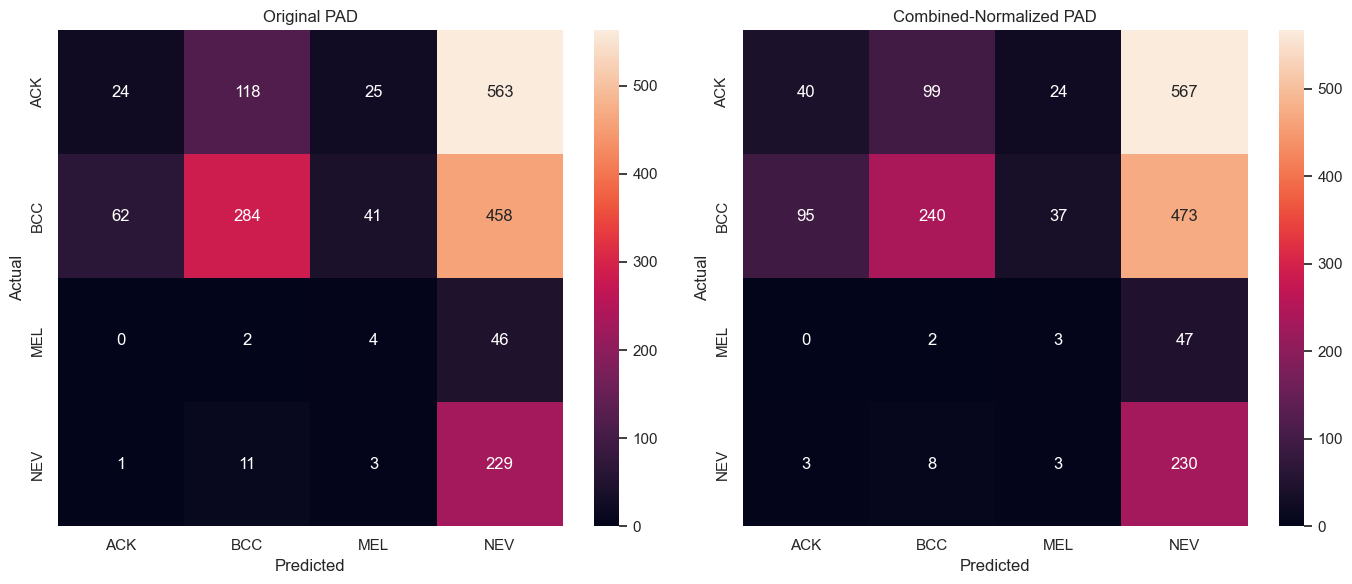

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    orig_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0]
)
axes[0].set_title("Original PAD")

sns.heatmap(
    norm_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1]
)
axes[1].set_title("Combined-Normalized PAD")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
results_dict = {
    "source_dataset_mean_rgb": ham_mean_rgb.tolist(),
    "source_dataset_std_rgb": ham_std_rgb.tolist(),
    "source_dataset_mean_brightness": ham_mean_brightness,
    "source_dataset_mean_contrast": ham_mean_contrast,
    "target_dataset_mean_rgb": pad_mean_rgb.tolist(),
    "target_dataset_std_rgb": pad_std_rgb.tolist(),
    "target_dataset_mean_brightness": pad_mean_brightness,
    "target_dataset_mean_contrast": pad_mean_contrast,
    "original_pad": {
        "accuracy": float(orig_acc_m),
        "precision": float(orig_prec),
        "recall": float(orig_rec),
        "f1": float(orig_f1),
        "auc": float(orig_auc)
    },
    "combined_normalized_pad": {
        "accuracy": float(norm_acc_m),
        "precision": float(norm_prec),
        "recall": float(norm_rec),
        "f1": float(norm_f1),
        "auc": float(norm_auc)
    }
}

with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results_dict, f, indent=2)

print("Saved results.json")

Saved results.json


In [19]:
pad_norm[["img_id", "label", "image_path"]].to_csv(
    OUT_DIR / "combined_normalized_pad_paths.csv",
    index=False
)

print("Saved normalized image path mapping.")

Saved normalized image path mapping.


In [20]:
print("\n--- COMBINED NORMALIZATION REPORT ---")
print("HAM mean RGB:", tuple(round(x, 2) for x in ham_mean_rgb))
print("PAD mean RGB:", tuple(round(x, 2) for x in pad_mean_rgb))
print(f"HAM mean brightness: {ham_mean_brightness:.2f}")
print(f"PAD mean brightness: {pad_mean_brightness:.2f}")
print(f"HAM mean contrast: {ham_mean_contrast:.2f}")
print(f"PAD mean contrast: {pad_mean_contrast:.2f}")
print(f"Original PAD F1: {orig_f1:.4f}")
print(f"Combined-Normalized PAD F1: {norm_f1:.4f}")
print(f"F1 gain: {norm_f1 - orig_f1:.4f}")
print(f"Original PAD AUC: {orig_auc:.4f}")
print(f"Combined-Normalized PAD AUC: {norm_auc:.4f}")


--- COMBINED NORMALIZATION REPORT ---
HAM mean RGB: (196.68, 138.93, 144.81)
PAD mean RGB: (169.9, 132.98, 117.59)
HAM mean brightness: 156.86
PAD mean brightness: 142.27
HAM mean contrast: 28.43
PAD mean contrast: 25.27
Original PAD F1: 0.2177
Combined-Normalized PAD F1: 0.2098
F1 gain: -0.0079
Original PAD AUC: 0.6664
Combined-Normalized PAD AUC: 0.6625
